# Amazon Reviews Sentiment Analysis

Explore the Amazon Product Reviews dataset, load trained models, and run predictions.

In [1]:
import sys
import os

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
from src.train_models import load_data
from src.flag_for_response import flag_for_response

## Load and Explore Data

In [2]:
df = load_data(sample_frac=0.1)
df.head(10)

,review,sentiment
165256,Having tried a couple of other brands of glute...,positive
231465,My cat loves these treats. If ever I can't fin...,positive
427827,A little less than I expected. It tends to ha...,neutral
433954,"First there was Frosted Mini-Wheats, in origin...",negative
70260,and I want to congratulate the graphic artist ...,positive
49866,Please add more Pineapple flavor to your packa...,positive
551047,I absolutely love Yorkshire tea and am so glad...,positive
18983,I have such a hard time finding loose tea loca...,positive
138968,"Previously, I've attempted a recipe with white...",positive
36352,I make pancakes or waffles every Saturday morn...,positive


<Axes: title={'center': 'Sentiment Distribution'}, xlabel='sentiment'>

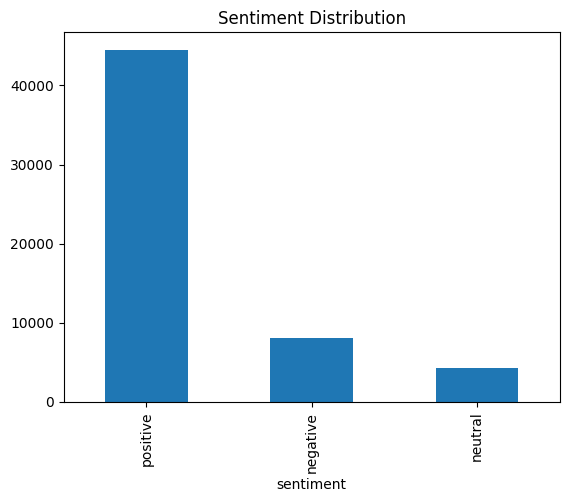

In [3]:
df['sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution')

## Load Model and Predict

In [4]:
import joblib

pipeline = joblib.load(os.path.join(PROJECT_ROOT, 'models', 'logisticregression_pipeline.joblib'))
sample_reviews = df['review'].head(5).tolist()
predictions = pipeline.predict(sample_reviews)

for text, pred in zip(sample_reviews[:3], predictions[:3]):
    print(f"{pred}: {text[:80]}...")

positive: Having tried a couple of other brands of gluten-free sandwich cookies, these are...
positive: My cat loves these treats. If ever I can't find her in the house, I just pop the...
negative: A little less than I expected.  It tends to have a muddy taste - not what I expe...


## Model Application Results Summary

Evaluate all trained models on the test set and compare performance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
MODEL_NAMES = ["logisticregression", "randomforest", "mlpclassifier"]
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

X = df["review"]
y = df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

results = []
for name in MODEL_NAMES:
    path = os.path.join(MODELS_DIR, f"{name}_pipeline.joblib")
    if not os.path.exists(path):
        continue
    pipeline = joblib.load(path)
    y_pred = pipeline.predict(X_test)
    results.append({
        "Model": name.replace("logisticregression", "Logistic Regression")
                      .replace("randomforest", "Random Forest")
                      .replace("mlpclassifier", "MLP Classifier"),
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted"),
    })

results_df = pd.DataFrame(results)
results_df

In [ ]:
# Bar chart: model comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
width = 0.25

ax.bar([i - width for i in x], results_df["Accuracy"], width, label="Accuracy")
ax.bar([i for i in x], results_df["F1 (macro)"], width, label="F1 (macro)")
ax.bar([i + width for i in x], results_df["F1 (weighted)"], width, label="F1 (weighted)")

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap: metrics by model
metrics_df = results_df.set_index("Model")[["Accuracy", "F1 (macro)", "F1 (weighted)"]]
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(metrics_df.T, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, vmin=0.5, vmax=1)
ax.set_title("Model Metrics Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrices for each model
labels = sorted(y_train.unique())
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name in zip(axes, MODEL_NAMES):
    path = os.path.join(MODELS_DIR, f"{name}_pipeline.joblib")
    if not os.path.exists(path):
        continue
    pipeline = joblib.load(path)
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    display_name = name.replace("logisticregression", "Logistic Regression").replace(
        "randomforest", "Random Forest"
    ).replace("mlpclassifier", "MLP Classifier")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels,
                yticklabels=labels, ax=ax)
    ax.set_title(display_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices by Model", y=1.02)
plt.tight_layout()
plt.show()

## Flag Reviews for Response

In [5]:
keywords = ['broken', 'refund', 'terrible', 'worst']
flagged = df.apply(lambda row: flag_for_response(row['review'], row['sentiment'], 
                                                   keywords=keywords), axis=1)
print(f"Flagged {flagged.sum()} reviews for response")

Flagged 2058 reviews for response
